# Who needs early help? Predicting long-term unemployment for UWV

**Hackathon 5 – Model Showdown · SDG 8 Decent Work and Economic Growth · De Haagse Hogeschool**

When someone in the Netherlands loses their job and claims unemployment benefit (WW), UWV uses an algorithm, the *Werkverkenner*, to estimate their chance of being back at work within a year. People with a chance below 50% are invited early for a face-to-face conversation with a work coach; everyone else starts with online services and is only seen in person after about three months.

This notebook builds a model for **that same decision** with open Dutch survey data (European Social Survey, rounds 4–11, 2008–2023): *will this person's unemployment last 12 months or longer?* We compare three scikit-learn classifiers – k-nearest neighbours, logistic regression and a random forest – against two baselines, check whether the model makes the same mistakes for different groups, and end with a recommendation for UWV.

The notebook follows the ten required steps in order. It runs from the raw CSV to the final prediction with *Restart & Run All*, in Google Colab, without extra installs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from pathlib import Path

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_validate, cross_val_predict, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (balanced_accuracy_score, recall_score, precision_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

RANDOM_STATE = 42          # used everywhere, so everyone gets the same numbers
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", None)
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 3.0.6 | numpy 2.4.6 | scikit-learn 1.9.1


In [2]:
# The raw ESS file (Dutch respondents, rounds 4-11, selected variable groups).
# Locally (or after cloning the repo) it is read from data/; in Colab it is downloaded from GitHub.
DATA_FILE = "ESS4e04_6-ESS5e03_6-ESS6e02_7-ESS7e02_3-ESS8e02_3-ESS9e03_3-ESS10e03_3-ESS11e04_2-subset.csv"
LOCAL_PATH = Path("data") / DATA_FILE
GITHUB_URL = "https://raw.githubusercontent.com/lucasjansze/Hackathon_5/main/data/" + DATA_FILE

source = LOCAL_PATH if LOCAL_PATH.exists() else GITHUB_URL
raw = pd.read_csv(source, low_memory=False)
print("Read from:", source)
print("Shape:", raw.shape)

Read from: data/ESS4e04_6-ESS5e03_6-ESS6e02_7-ESS7e02_3-ESS8e02_3-ESS9e03_3-ESS10e03_3-ESS11e04_2-subset.csv
Shape: (13890, 827)


## Step 1 – Frame the problem

**Decision and user.** The user is UWV: the work coaches who hold intake conversations with new WW claimants, and the team that decides who is invited early. The decision is *invite this person early for a face-to-face conversation – yes or no*. Counsellor time is limited, so UWV cannot invite everyone in month one.

**Who the prediction is about.** People of working age (18–66) in the Netherlands who recently became unemployed and were looking for work for at least three months.

**Target and positive class.** `uemp12m` – *did a period of unemployment and job seeking last 12 months or longer?* The positive class (1) is **long-term unemployed**: the person who most needs early help.

**Which mistake is worse?**
- A **false negative** is a person who will be unemployed for a year or more, but is predicted to find work quickly. They are not invited early and lose months without help while their benefit runs down. UWV's own evaluation found that personal help raises the chance of work by about 2 percentage points, so missing someone costs them real chances.
- A **false positive** is a person who would have found work anyway but is invited early. That costs one conversation of a work coach's time.

So a false negative is worse.

**Main metric: balanced accuracy.** Our first instinct was recall, but in this data the positive class is the *majority* (about 51%). A `DummyClassifier` that predicts the most common class therefore invites *everyone* and gets a perfect recall of 1.0 – which is exactly the situation of having no model at all. Recall alone can never be beaten by a real model and rewards inviting everybody, which UWV cannot afford. Balanced accuracy is the average of the recall for the long-term group and the recall for the short-term group: inviting everyone scores 0.5. It forces a model to find the long-term unemployed *and* not invite people who would manage on their own. We compare and tune all models on balanced accuracy, always report recall and precision next to it, and in step 9 we deliberately move the decision threshold so that recall for the long-term group becomes high – because a missed person is the more costly mistake.

## Step 2 – Explore the data

### 2a. What is in the raw file?
Every row is one respondent of the European Social Survey in the Netherlands. ESS interviews a new random sample of Dutch residents every two years, so nobody appears in two rounds.

In [3]:
round_years = {4: "2008", 5: "2010", 6: "2012", 7: "2014", 8: "2016", 9: "2018", 10: "2020-22", 11: "2023-24"}
overview = raw.groupby("essround").agg(respondents=("idno", "size"), edition=("edition", "first"))
overview.insert(0, "fieldwork", overview.index.map(round_years))
print("Countries in file:", raw["cntry"].unique().tolist())
overview

Countries in file: ['NL']


,fieldwork,respondents,edition
essround,,,
4,2008,1778,4.6
5,2010,1829,3.6
6,2012,1845,2.7
7,2014,1919,2.3
8,2016,1681,2.3
9,2018,1673,3.3
10,2020-22,1470,3.3
11,2023-24,1695,4.2


### 2b. Who do we predict for? (population filter)
We keep respondents who (1) were ever unemployed and looking for work for more than three months, (2) had such a period in the **last five years**, (3) are of working age, and (4) answered the target question. The five-year filter matters: without it, someone's unemployment could have been 30 years ago while their household and education are measured today. Defining the population is not cleaning, so it happens before the split.

In [4]:
funnel = [("All Dutch respondents, rounds 4-11", len(raw))]
pop = raw[raw["uemp3m"] == 1]
funnel.append(("Ever unemployed and looking for work > 3 months", len(pop)))
pop = pop[pop["uemp5yr"] == 1]
funnel.append(("... and such a period in the last 5 years", len(pop)))
pop = pop[pop["agea"].between(18, 66)]
funnel.append(("... and aged 18-66", len(pop)))
pop = pop[pop["uemp12m"].isin([1, 2])]          # 1 = yes, 2 = no; 7/8/9 = refusal / don't know / no answer
funnel.append(("... and answered the target question", len(pop)))
pop = pop.copy()

y = (pop["uemp12m"] == 1).astype(int)            # 1 = long-term unemployed (12+ months)
display(pd.DataFrame(funnel, columns=["filter", "rows"]))
print(f"Class balance: {y.mean():.1%} long-term (1), {1 - y.mean():.1%} shorter (0)")

,filter,rows
0,"All Dutch respondents, rounds 4-11",13890
1,Ever unemployed and looking for work > 3 months,3062
2,... and such a period in the last 5 years,1196
3,... and aged 18-66,1165
4,... and answered the target question,1163


Class balance: 51.5% long-term (1), 48.5% shorter (0)


### 2c. Missing values in disguise
ESS stores *not applicable*, *refusal*, *don't know* and *no answer* as numbers – for example `7`, `8`, `9`, `77`, `88`, `99`, `999` or `66666`. If we fed those to a model, an age of 999 or an education level of 88 would look like real values. Below we translate every variable we use into readable values and turn these codes into proper missing values (`NaN`). These are row-by-row translations of a codebook – nothing is learned from the data – so they are safe to do before the split.

Two job variables have a real *not applicable* answer (for example: a self-employed person has no employment contract). We keep that as its own category instead of treating it as missing.

In [5]:
def keep_valid(series, valid_values):
    # Keep only the codes listed as valid; every other code becomes NaN.
    return series.where(series.isin(valid_values))

def labels(series, mapping):
    # Translate codes into readable labels; codes not in the mapping (7/8/9 etc.) become NaN.
    return series.map(mapping)

household_cols = [c for c in pop.columns if c.startswith("rshipa")]   # relation of each household member

def occupation_group(row):
    # ISCO major group (first digit) of current or last job. ISCO-88 in rounds 4-5, ISCO-08 from round 6.
    code = row["isco08"] if row["essround"] >= 6 else row["iscoco"]
    if pd.isna(code) or code in (77777, 88888, 99999):
        return np.nan
    if code == 66666:
        return "not applicable"
    names = {0: "armed forces", 1: "managers", 2: "professionals", 3: "technicians",
             4: "clerical support", 5: "service and sales", 6: "skilled agriculture",
             7: "craft and trades", 8: "machine operators", 9: "elementary occupations"}
    return names[int(code) // 1000]

def sector_group(row):
    # Broad sector of current or last job. NACE Rev.1.1 in round 4, NACE Rev.2 from round 5.
    if row["essround"] >= 5:
        code, bounds = row["nacer2"], [(3, "agriculture"), (39, "industry and energy"), (43, "construction"),
                                       (56, "trade, transport and hospitality"), (82, "business services"),
                                       (88, "public sector, education and health"), (99, "other services")]
    else:
        code, bounds = row["nacer11"], [(5, "agriculture"), (41, "industry and energy"), (45, "construction"),
                                        (63, "trade, transport and hospitality"), (74, "business services"),
                                        (85, "public sector, education and health"), (99, "other services")]
    if pd.isna(code) or code in (777, 888, 999):
        return np.nan
    if code == 666:
        return "not applicable"
    for upper, name in bounds:
        if code <= upper:
            return name
    return np.nan

data = pd.DataFrame(index=pop.index)
data["age"] = pop["agea"]
data["education_level"] = keep_valid(pop["eisced"], range(1, 8))            # ES-ISCED 1 (lowest) .. 7 (master+)
data["father_education"] = keep_valid(pop["eiscedf"], range(1, 8))
data["mother_education"] = keep_valid(pop["eiscedm"], range(1, 8))
data["household_size"] = keep_valid(pop["hhmmb"], range(1, 21))
data["gender"] = labels(pop["gndr"], {1: "male", 2: "female"})
data["lives_with_partner"] = np.where(pop[household_cols].eq(1).any(axis=1), "yes", "no")
data["children_at_home"] = np.where(pop[household_cols].eq(2).any(axis=1), "yes", "no")
data["area"] = labels(pop["domicil"], {1: "big city", 2: "suburbs", 3: "town", 4: "village", 5: "countryside"})
data["region"] = pop["region"]                                               # province (NUTS-2); not asked in round 4
data["contract"] = labels(pop["wrkctra"], {1: "permanent", 2: "temporary", 3: "no contract", 6: "not applicable"})
data["employment_relation"] = labels(pop["emplrel"], {1: "employee", 2: "self-employed", 3: "family business", 6: "not applicable"})
data["workplace_size"] = labels(pop["estsz"], {1: "<10", 2: "10-24", 3: "25-99", 4: "100-499", 5: "500+", 6: "not applicable"})
data["supervisor"] = labels(pop["jbspv"], {1: "yes", 2: "no", 6: "not applicable"})
data["occupation_group"] = pop.apply(occupation_group, axis=1)
data["sector_group"] = pop.apply(sector_group, axis=1)

# Migration background (CBS-style): only used for the fairness checks in step 8, NOT as a model feature.
born_nl, father_nl, mother_nl = pop["brncntr"], pop["facntr"], pop["mocntr"]
data["origin"] = np.select(
    [born_nl == 2,
     (born_nl == 1) & ((father_nl == 2) | (mother_nl == 2)),
     (born_nl == 1) & (father_nl == 1) & (mother_nl == 1)],
    ["born abroad", "born in NL, parent born abroad", "born in NL, parents born in NL"],
    default="unknown")
data["origin"] = data["origin"].replace("unknown", np.nan)

data.head()

,age,education_level,father_education,mother_education,household_size,gender,lives_with_partner,children_at_home,area,region,contract,employment_relation,workplace_size,supervisor,occupation_group,sector_group,origin
0,18,2.0,NaN,2.0,3,female,no,yes,big city,NaN,temporary,employee,100-499,no,clerical support,"trade, transport and hospitality","born in NL, parents born in NL"
2,42,2.0,NaN,1.0,4,female,no,yes,big city,NaN,temporary,employee,<10,no,service and sales,"trade, transport and hospitality",born abroad
9,29,3.0,1.0,NaN,2,male,yes,no,town,NaN,temporary,employee,<10,no,managers,"trade, transport and hospitality",born abroad
24,55,7.0,6.0,4.0,1,male,no,no,suburbs,NaN,permanent,employee,25-99,yes,professionals,other services,"born in NL, parents born in NL"
47,43,2.0,2.0,1.0,5,female,yes,yes,big city,NaN,temporary,employee,500+,no,service and sales,"public sector, education and health",born abroad


In [6]:
missing = data.isna().mean().mul(100).round(1).sort_values(ascending=False)
missing.to_frame("% missing")

,% missing
father_education,13.5
region,11.7
mother_education,8.9
workplace_size,2.1
sector_group,1.5
employment_relation,1.1
education_level,0.8
contract,0.7
occupation_group,0.4
supervisor,0.3


`region` is missing for every respondent of round 4 (the question was not asked then); in the pipeline it gets its own category *missing*. The parents' education has some *don't know* answers. Everything else is almost complete.

### 2d. Impossible or inconsistent values

In [7]:
checks = {
    "age outside 18-66": (~data["age"].between(18, 66)).sum(),
    "household size 1 but lives with partner": ((data["household_size"] == 1) & (data["lives_with_partner"] == "yes")).sum(),
    "household size 1 but children at home": ((data["household_size"] == 1) & (data["children_at_home"] == "yes")).sum(),
    "education level outside 1-7": (~data["education_level"].dropna().between(1, 7)).sum(),
}
pd.Series(checks, name="rows")

age outside 18-66                          0
household size 1 but lives with partner    0
household size 1 but children at home      0
education level outside 1-7                0
Name: rows, dtype: int64

### 2e. Duplicates

In [8]:
print("Same respondent twice (round + id):", pop.duplicated(subset=["essround", "idno"]).sum())
print("Rows with exactly the same feature values:", data.drop(columns="origin").duplicated().sum())

Same respondent twice (round + id): 0
Rows with exactly the same feature values: 0


No respondent appears twice, and no two respondents have exactly the same answers on all features, so no copy of a person can end up in both the training and the test set.

### 2f. Columns that leak the answer
Some columns are only known *after* the outcome, or are a *consequence* of long unemployment. The clearest example is `mnactic`, the respondent's main activity *now*. Someone who is still unemployed at the interview is very likely in a long spell:

In [9]:
activity = labels(pop["mnactic"], {1: "paid work", 2: "education", 3: "unemployed, looking",
                                   4: "unemployed, not looking", 5: "sick or disabled",
                                   6: "retired", 8: "housework", 9: "other"})
leak = pd.DataFrame({"activity now": activity, "long-term": y}).groupby("activity now")["long-term"].agg(["size", "mean"])
leak.columns = ["rows", "share long-term"]
leak.sort_values("share long-term", ascending=False).round(2)

,rows,share long-term
activity now,,
"unemployed, not looking",94,0.78
sick or disabled,60,0.75
"unemployed, looking",179,0.74
retired,19,0.74
other,29,0.72
housework,145,0.59
paid work,568,0.35
education,63,0.35


74% of people who are unemployed *now* had a long spell, against 35% of people in paid work. At UWV's intake moment this information does not exist yet – everyone at intake is unemployed – so using it would make our scores look great and be useless in practice. We therefore **drop** these columns:

| Dropped column | Why |
|---|---|
| `mnactic`, `uempla`, `uempli`, `crpdwk`, `pdjobyr` | current activity / year of last job: describe the situation *after* the unemployment |
| `hinctnta`, `hincfel`, `hincsrca` | household income, difficulty living on income, main income source: consequences of long unemployment |
| `health`, `hlthhmp` | can be a cause *and* a consequence of long unemployment; measured at the interview, not at intake |
| `uemp3m`, `uemp5yr` | used for the population filter, constant afterwards |
| `idno`, `essround`, `cntry`, weights | identifiers and survey administration, not characteristics of a person |
| migration background (`brncntr`, `facntr`, `mocntr`) | kept *out* of the model on purpose; used only to check fairness (step 8) |

### 2g. Distributions: who is long-term unemployed?

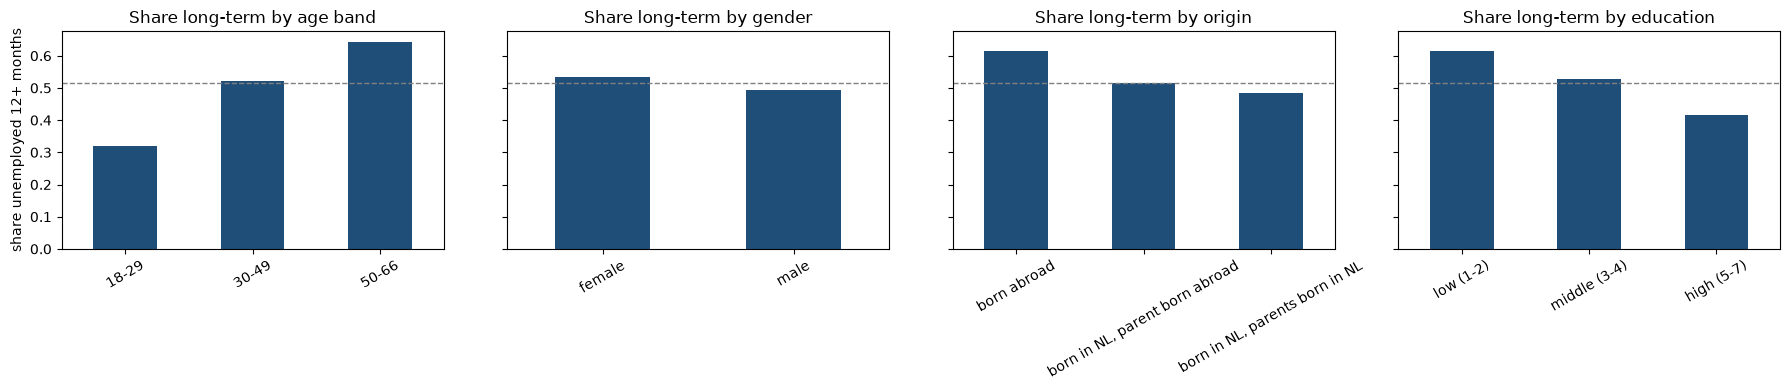

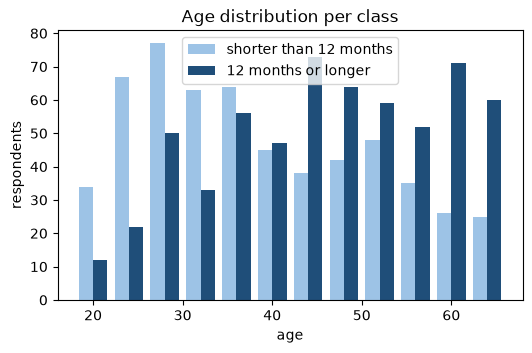

In [10]:
info = pd.DataFrame(index=data.index)
info["age band"] = pd.cut(data["age"], [17, 29, 49, 66], labels=["18-29", "30-49", "50-66"])
info["gender"] = data["gender"]
info["origin"] = data["origin"]
info["education"] = pd.cut(data["education_level"], [0, 2, 4, 7], labels=["low (1-2)", "middle (3-4)", "high (5-7)"])

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, col in zip(axes, info.columns):
    rate = y.groupby(info[col], observed=True).mean()
    rate.plot.bar(ax=ax, color="#1f4e79")
    ax.axhline(y.mean(), color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"Share long-term by {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("share unemployed 12+ months")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist([data.loc[y == 0, "age"], data.loc[y == 1, "age"]], bins=range(18, 68, 4),
        label=["shorter than 12 months", "12 months or longer"], color=["#9dc3e6", "#1f4e79"])
ax.set_xlabel("age"); ax.set_ylabel("respondents"); ax.legend(); ax.set_title("Age distribution per class")
plt.show()

The same patterns CBS reports for the whole country show up here: long-term unemployment rises steeply with age (about one in three under 30, about two in three over 50), is more common with lower education, and more common for people born abroad. Men and women differ little. The dashed line is the overall share (51%).

## Step 3 – Split first
We set aside 20% of the rows as a test set **before** any imputing, scaling or tuning. The split is stratified, so both parts have the same share of long-term unemployed, and uses a fixed `random_state`. The test set is used exactly once, in step 7.

In [11]:
NUMERIC = ["age", "education_level", "father_education", "mother_education", "household_size"]
CATEGORICAL = ["gender", "lives_with_partner", "children_at_home", "area", "region", "contract",
               "employment_relation", "workplace_size", "supervisor", "occupation_group", "sector_group"]
FEATURES = NUMERIC + CATEGORICAL

X = data[FEATURES]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
info_train, info_test = info.loc[X_train.index], info.loc[X_test.index]

print(f"Train: {len(X_train)} rows ({y_train.mean():.1%} long-term)")
print(f"Test:  {len(X_test)} rows ({y_test.mean():.1%} long-term)")
print(f"{len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical features")

Train: 930 rows (51.5% long-term)
Test:  233 rows (51.5% long-term)
5 numeric + 11 categorical features


## Step 4 – Pre-processing inside a Pipeline
All pre-processing lives inside one `ColumnTransformer`, which becomes the first step of every model's `Pipeline`. That way the imputer and scaler are fitted on the training folds only – also inside cross-validation – and never see the validation fold or the test set.

- **Numeric columns:** missing values get the median of the training data, then `StandardScaler` gives every column mean 0 and standard deviation 1.
- **Categorical columns:** missing values become their own category `"missing"` (for example region in round 4), then one-hot encoding turns every category into a 0/1 column. Categories with fewer than 10 people in the training data (for example *armed forces*: 2 people) are grouped into one *infrequent* column: a pattern learned from two people is noise, not knowledge. A category that only appears in the test set is put in that same column instead of crashing the model.

**Why scaling matters.** KNN decides by *distance*: without scaling, age (range 18–66) would dominate a 0/1 column like *temporary contract* simply because its numbers are bigger. Logistic regression with regularisation (`C`) penalises large coefficients, which is only fair if all features are on the same scale. A random forest does not need scaling, but it gets exactly the same pipeline so the comparison stays fair.

In [12]:
def make_preprocessor():
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                            ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10))])
    return ColumnTransformer([("num", numeric, NUMERIC),
                              ("cat", categorical, CATEGORICAL)])

n_columns = make_preprocessor().fit_transform(X_train).shape[1]
print("Columns after one-hot encoding (fitted on training data only):", n_columns)

Columns after one-hot encoding (fitted on training data only): 70


## Step 5 – Baselines
Every model has to beat two baselines, measured with the same 5 cross-validation folds on the training set:

1. **`DummyClassifier(most_frequent)`** – always predicts the largest class. Because long-term is the (small) majority, it invites everyone: recall 1.0 but balanced accuracy 0.5. This is "no model at all".
2. **A one-feature rule: invite everyone aged 50 or older.** This is the simple alternative a work coach could apply in their head, and CBS reports that older job seekers are most often long-term unemployed. If a model cannot beat this rule, machine learning adds nothing.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # the SAME folds for every model
SCORING = "balanced_accuracy"

class AgeRule(BaseEstimator, ClassifierMixin):
    # Predicts 1 (long-term) for everyone at or above the age threshold. Learns nothing from the data.
    def __init__(self, age_threshold=50):
        self.age_threshold = age_threshold
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self
    def predict(self, X):
        return (X["age"] >= self.age_threshold).astype(int).to_numpy()

baselines = {
    "Baseline: most frequent": Pipeline([("prep", make_preprocessor()),
                                         ("model", DummyClassifier(strategy="most_frequent"))]),
    "Baseline: age >= 50": AgeRule(age_threshold=50),
}
rows = []
for name, model in baselines.items():
    res = cross_validate(model, X_train, y_train, cv=cv, return_train_score=True,
                         scoring=["balanced_accuracy", "recall", "precision"])
    rows.append({"model": name,
                 "CV balanced accuracy": f"{res['test_balanced_accuracy'].mean():.3f} ± {res['test_balanced_accuracy'].std():.3f}",
                 "CV recall": round(res["test_recall"].mean(), 3),
                 "CV precision": round(res["test_precision"].mean(), 3)})
pd.DataFrame(rows)

,model,CV balanced accuracy,CV recall,CV precision
0,Baseline: most frequent,0.500 ± 0.000,1.000,0.515
1,Baseline: age >= 50,0.590 ± 0.038,0.413,0.653


The dummy indeed has recall 1.0 and balanced accuracy 0.5. The age rule is a real competitor: with one feature it already finds the long-term unemployed better than chance, but it misses most of them (low recall), because many long-term unemployed people are younger than 50.

## Step 6 – Tune with cross-validation
All three models are tuned with `GridSearchCV` on the **training set only**, with the **same 5 folds** (`cv`) and the **same metric** (balanced accuracy).

| Model | Hyperparameters we tune | Why these |
|---|---|---|
| KNN | `n_neighbors` 1–51 (odd), `weights` uniform/distance | few neighbours = memorises noise, many = too smooth |
| Logistic regression | `C` 0.001–100, `class_weight` None/balanced | small `C` = strong regularisation (simpler model) |
| Random forest | `max_depth`, `min_samples_leaf`, `class_weight` | depth and leaf size control how much each tree can memorise |

In [14]:
candidates = {
    "KNN": (KNeighborsClassifier(),
            {"model__n_neighbors": list(range(1, 52, 2)),
             "model__weights": ["uniform", "distance"]}),
    "Logistic regression": (LogisticRegression(max_iter=1000),
            {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
             "model__class_weight": [None, "balanced"]}),
    "Random forest": (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
            {"model__max_depth": [3, 5, 8, 12, None],
             "model__min_samples_leaf": [1, 5, 20],
             "model__class_weight": [None, "balanced"]}),
}

searches = {}
for name, (estimator, grid) in candidates.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", estimator)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring=SCORING, return_train_score=True, n_jobs=-1)
    search.fit(X_train, y_train)
    searches[name] = search

tuning = []
for name, s in searches.items():
    i = s.best_index_
    tuning.append({"model": name,
                   "best hyperparameters": {k.replace("model__", ""): v for k, v in s.best_params_.items()},
                   "CV balanced accuracy (mean ± std)": f"{s.cv_results_['mean_test_score'][i]:.3f} ± {s.cv_results_['std_test_score'][i]:.3f}",
                   "train balanced accuracy": round(s.cv_results_["mean_train_score"][i], 3)})
pd.DataFrame(tuning)

,model,best hyperparameters,CV balanced accuracy (mean ± std),train balanced accuracy
0,KNN,"{'n_neighbors': 47, 'weights': 'uniform'}",0.643 ± 0.052,0.657
1,Logistic regression,"{'C': 10, 'class_weight': 'balanced'}",0.674 ± 0.016,0.715
2,Random forest,"{'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 20}",0.672 ± 0.035,0.702


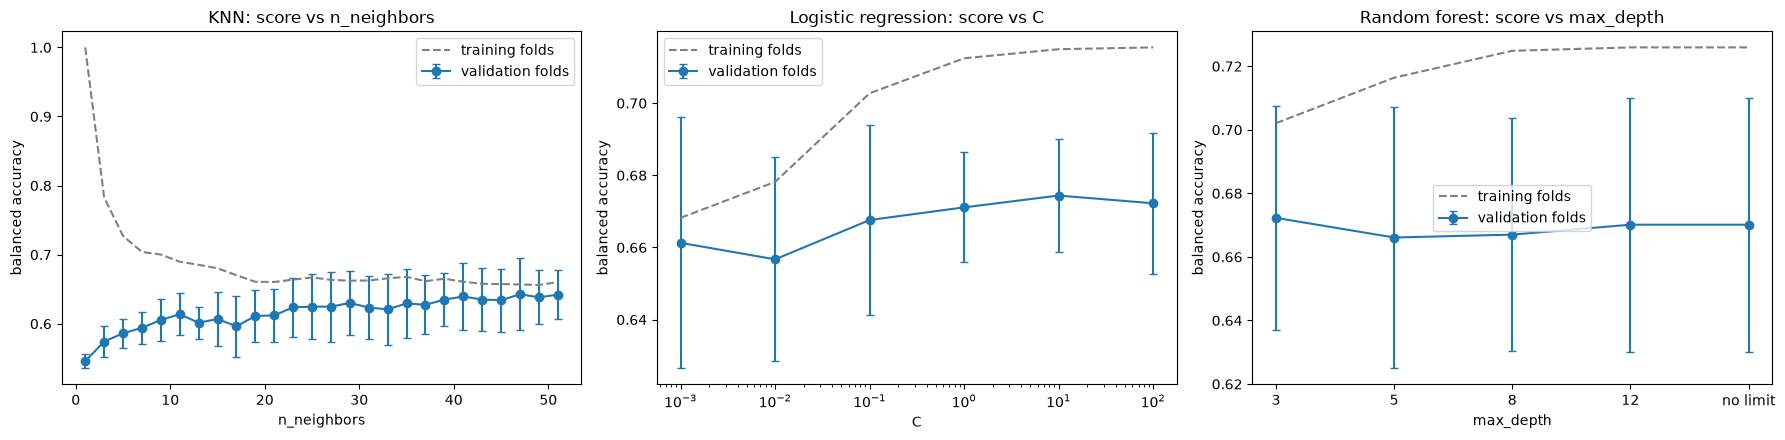

In [15]:
def as_text(values):
    # Hyperparameter values as text, so None / numbers can be compared safely.
    return values.map(lambda v: "None" if v is None or (isinstance(v, float) and np.isnan(v)) else str(v))

def plot_curve(ax, search, param, fixed, log=False, title=""):
    # Mean CV score (with spread over the 5 folds) against one hyperparameter, others fixed.
    res = pd.DataFrame(search.cv_results_)
    for p, v in fixed.items():
        res = res[as_text(res[f"param_{p}"]) == str(v)]
    x = res[f"param_{param}"].astype(float)
    ax.errorbar(x, res["mean_test_score"], yerr=res["std_test_score"], marker="o", capsize=3, label="validation folds")
    ax.plot(x, res["mean_train_score"], linestyle="--", color="grey", label="training folds")
    if log:
        ax.set_xscale("log")
    ax.set_xlabel(param.replace("model__", "")); ax.set_ylabel("balanced accuracy")
    ax.set_title(title); ax.legend()

knn, lr, rf = searches["KNN"], searches["Logistic regression"], searches["Random forest"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_curve(axes[0], knn, "model__n_neighbors", {"model__weights": knn.best_params_["model__weights"]},
           title="KNN: score vs n_neighbors")
plot_curve(axes[1], lr, "model__C", {"model__class_weight": lr.best_params_["model__class_weight"]},
           log=True, title="Logistic regression: score vs C")
rf_res = pd.DataFrame(rf.cv_results_)
rf_res = rf_res[(as_text(rf_res["param_model__min_samples_leaf"]) == str(rf.best_params_["model__min_samples_leaf"])) &
                (as_text(rf_res["param_model__class_weight"]) == str(rf.best_params_["model__class_weight"]))]
depth_labels = as_text(rf_res["param_model__max_depth"]).replace("None", "no limit")
axes[2].errorbar(depth_labels, rf_res["mean_test_score"], yerr=rf_res["std_test_score"], marker="o", capsize=3, label="validation folds")
axes[2].plot(depth_labels, rf_res["mean_train_score"], linestyle="--", color="grey", label="training folds")
axes[2].set_xlabel("max_depth"); axes[2].set_ylabel("balanced accuracy"); axes[2].legend()
axes[2].set_title("Random forest: score vs max_depth")
plt.tight_layout()
plt.show()

**How to read these plots.** The grey dashed line is the score on the folds the model was trained on, the blue line the score on the held-out fold, with the spread over the five folds as error bars.
- **KNN:** with 1 neighbour the training score is perfect (1.00) and the validation score poor (0.55) – the model memorises individuals. As `n_neighbors` grows the gap closes; from about 40 neighbours the validation score levels off around 0.63–0.64. The best value (47) lies near the end of the grid, but the curve is flat there, so a larger grid would not change the picture.
- **Logistic regression:** with very small `C` (strong regularisation) the validation score is about 0.66; from `C = 0.1` it is flat around 0.67. The chosen `C = 10` (0.674) is not meaningfully better than `C = 1` (0.671).
- **Random forest:** deeper trees fit the training folds better (0.70 at depth 3, 0.73 without a depth limit), but the validation score stays flat around 0.67 – extra depth only memorises the training data. The shallowest trees (depth 3) are as good as any.

In all three plots the differences between the best few settings are **smaller than the spread over the folds** (about ± 0.02 to ± 0.05), so the exact best value should not be over-interpreted.

## Step 7 – Evaluate once on the test set
Now – and only now – every tuned model (refitted on the full training set by `GridSearchCV`) and both baselines predict the test set.

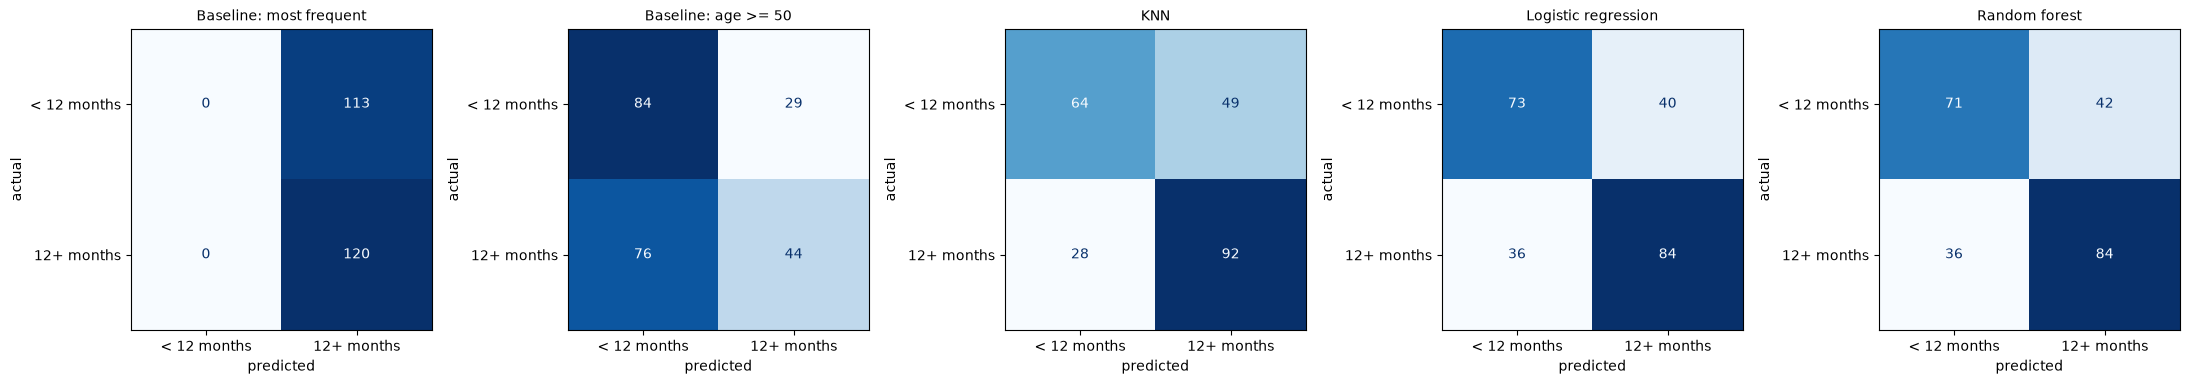

In [16]:
final_models = {name: model.fit(X_train, y_train) for name, model in baselines.items()}
final_models.update({name: s.best_estimator_ for name, s in searches.items()})

test_pred = {name: m.predict(X_test) for name, m in final_models.items()}

fig, axes = plt.subplots(1, len(test_pred), figsize=(22, 4))
for ax, (name, pred) in zip(axes, test_pred.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["< 12 months", "12+ months"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout()
plt.show()

In [17]:
def scores(y_true, pred):
    return {"balanced accuracy": balanced_accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred),
            "F1": f1_score(y_true, pred)}

# Train vs CV vs test balanced accuracy: the gaps tell us about over- and underfitting
gap_rows = []
for name, model in final_models.items():
    if name in searches:
        s = searches[name]
        cv_score = s.cv_results_["mean_test_score"][s.best_index_]
    else:
        cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring=SCORING).mean()
    gap_rows.append({"model": name,
                     "train": balanced_accuracy_score(y_train, model.predict(X_train)),
                     "cross-validation": cv_score,
                     "test": balanced_accuracy_score(y_test, test_pred[name])})
pd.DataFrame(gap_rows).set_index("model").round(3)

,train,cross-validation,test
model,,,
Baseline: most frequent,0.500,0.500,0.500
Baseline: age >= 50,0.590,0.590,0.555
KNN,0.666,0.643,0.667
Logistic regression,0.713,0.674,0.673
Random forest,0.707,0.672,0.664


In [18]:
# The required comparison table, baseline first
comparison = []
for name, pred in test_pred.items():
    if name in searches:
        s = searches[name]
        params = {k.replace("model__", ""): v for k, v in s.best_params_.items()}
        cv_text = f"{s.cv_results_['mean_test_score'][s.best_index_]:.3f} ± {s.cv_results_['std_test_score'][s.best_index_]:.3f}"
    else:
        params = "-" if "most" in name else {"age_threshold": 50}
        res = cross_val_score(final_models[name], X_train, y_train, cv=cv, scoring=SCORING)
        cv_text = f"{res.mean():.3f} ± {res.std():.3f}"
    row = {"model": name, "best hyperparameters": params, "CV balanced accuracy": cv_text}
    row.update({f"test {k}": round(v, 3) for k, v in scores(y_test, pred).items()})
    comparison.append(row)
comparison_table = pd.DataFrame(comparison)
comparison_table

,model,best hyperparameters,CV balanced accuracy,test balanced accuracy,test precision,test recall,test F1
0,Baseline: most frequent,-,0.500 ± 0.000,0.500,0.515,1.000,0.680
1,Baseline: age >= 50,{'age_threshold': 50},0.590 ± 0.038,0.555,0.603,0.367,0.456
2,KNN,"{'n_neighbors': 47, 'weights': 'uniform'}",0.643 ± 0.052,0.667,0.652,0.767,0.705
3,Logistic regression,"{'C': 10, 'class_weight': 'balanced'}",0.674 ± 0.016,0.673,0.677,0.700,0.689
4,Random forest,"{'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 20}",0.672 ± 0.035,0.664,0.667,0.700,0.683


**What the gaps tell us.** *(numbers in the two tables above)*
- **Logistic regression** (train 0.71 / CV 0.67 / test 0.67) and the **random forest** (0.71 / 0.67 / 0.66) both score about 0.04 higher on the data they were trained on: a little memorisation (mild overfitting), but not much – the tuning chose strong enough limits (a shallow forest, a regularised regression).
- **KNN** with 47 neighbours has almost no gap (0.67 / 0.64 / 0.67): it averages over so many neighbours that it cannot memorise – if anything it is a bit too simple (underfitting), which also explains its lower CV score.
- For every model the test score lies within about one standard deviation of its CV score, so the test set confirms the cross-validation instead of contradicting it. The three models end up within 0.01 of each other on the test set.
- All three models clearly beat the dummy (0.50) and the age rule (0.56 on the test set), mainly because they find far more of the long-term unemployed: recall 0.70–0.77 against 0.37 for the age rule.
- **None of the models is strong**: a balanced accuracy around 0.67 means roughly one in three predictions is wrong. Survey answers about background and previous job only partly explain who stays unemployed.

## Step 8 – Look at the errors
We continue with the model that had the best **cross-validation** score (not the best test score – choosing on the test set would be tuning on it).

In [19]:
best_name = max(searches, key=lambda n: searches[n].best_score_)
best_model = final_models[best_name]
best_pred = test_pred[best_name]
print("Model with the best CV balanced accuracy:", best_name)

errors = info_test.copy()
errors["actual"] = y_test
errors["predicted"] = best_pred
errors["result"] = np.select(
    [(errors.actual == 1) & (errors.predicted == 1), (errors.actual == 1) & (errors.predicted == 0),
     (errors.actual == 0) & (errors.predicted == 1)],
    ["correct: long-term", "MISSED (false negative)", "extra invite (false positive)"], default="correct: shorter")
print(errors["result"].value_counts().to_string())

Model with the best CV balanced accuracy: Logistic regression
result
correct: long-term               84
correct: shorter                 73
extra invite (false positive)    40
MISSED (false negative)          36


In [20]:
def group_report(frame, group_col):
    rows = []
    for group, g in frame.groupby(group_col, observed=True):
        rows.append({"group": f"{group_col}: {group}", "test rows": len(g),
                     "share long-term": round(g.actual.mean(), 2),
                     "recall": round(recall_score(g.actual, g.predicted, zero_division=0), 2),
                     "precision": round(precision_score(g.actual, g.predicted, zero_division=0), 2),
                     "missed (FN)": int(((g.actual == 1) & (g.predicted == 0)).sum())})
    return pd.DataFrame(rows)

subgroups = pd.concat([group_report(errors, c) for c in ["gender", "age band", "origin", "education"]], ignore_index=True)
subgroups

,group,test rows,share long-term,recall,precision,missed (FN)
0,gender: female,140,0.51,0.74,0.68,19
1,gender: male,93,0.52,0.65,0.67,17
2,age band: 18-29,52,0.33,0.35,0.67,11
3,age band: 30-49,108,0.55,0.66,0.75,20
4,age band: 50-66,73,0.60,0.89,0.62,5
5,origin: born abroad,38,0.71,0.81,0.88,5
6,"origin: born in NL, parent born abroad",25,0.48,0.50,0.60,6
7,"origin: born in NL, parents born in NL",170,0.48,0.69,0.63,25
8,education: low (1-2),74,0.68,0.86,0.72,7
9,education: middle (3-4),74,0.47,0.66,0.64,12


**Who does the model miss?** The errors are not evenly spread:
- **Young people:** of the long-term unemployed aged 18–29 the model finds only 35%; for 50–66 it finds 89%. The model has learned that age predicts long-term unemployment, so a young person who *does* get stuck looks like someone who will find work quickly.
- **Higher-educated people:** recall 0.51 against 0.86 for low education – the same mechanism.
- **Men vs women:** recall 0.65 for men against 0.74 for women, while both groups are equally often long-term unemployed (52% and 51%). With 93 men in the test set this is a few people, but it is a reason for extra caution.
- **Migration background:** people born abroad are found well (0.81); people born in the Netherlands with a parent born abroad less often (0.50) – but that group has only 25 test rows, so this is a handful of people.

Some groups are small, so these numbers are uncertain. Still, the direction matters for UWV: a model like this would systematically give *less* early help to young and higher-educated long-term unemployed people.

### 8b. Fairness experiment: with or without migration background?
CBS figures and our own data show that people born abroad are more often long-term unemployed. Should UWV's model use migration background? Using it could steer help to people who need it – but it is also exactly the kind of profiling the SyRI judgment (District Court of The Hague, 2020) and the childcare benefits scandal warned against. We test it with cross-validation on the **training set** (the test set stays untouched): the same model, once without and once with `origin` as a feature.

In [21]:
def prep_with(extra_cat):
    numeric = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    categorical = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                            ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=10))])
    return ColumnTransformer([("num", numeric, NUMERIC), ("cat", categorical, CATEGORICAL + extra_cat)])

best_params = {k: v for k, v in searches[best_name].best_params_.items()}
X_train_origin = X_train.assign(origin=data.loc[X_train.index, "origin"])

experiment = {}
for label, cols in [("without origin", []), ("with origin", ["origin"])]:
    pipe = Pipeline([("prep", prep_with(cols)), ("model", candidates[best_name][0])]).set_params(**best_params)
    experiment[label] = cross_val_predict(pipe, X_train_origin, y_train, cv=cv)

rows = []
for label, pred in experiment.items():
    row = {"model": f"{best_name} {label}",
           "CV balanced accuracy (all)": round(balanced_accuracy_score(y_train, pred), 3)}
    for group in info_train["origin"].dropna().unique():
        mask = (info_train["origin"] == group).to_numpy()
        row[f"recall – {group}"] = round(recall_score(y_train[mask], pred[mask]), 2)
    rows.append(row)
pd.DataFrame(rows)

,model,CV balanced accuracy (all),"recall – born in NL, parents born in NL",recall – born abroad,"recall – born in NL, parent born abroad"
0,Logistic regression without origin,0.674,0.68,0.70,0.58
1,Logistic regression with origin,0.676,0.65,0.76,0.63


In [22]:
# Proxy check: can the features we DID keep guess someone's migration background?
known = data.loc[X_train.index, "origin"].notna()
origin_target = (data.loc[X_train.index, "origin"][known] != "born in NL, parents born in NL").astype(int)
proxy = Pipeline([("prep", make_preprocessor()), ("model", LogisticRegression(max_iter=1000))])
auc = cross_val_score(proxy, X_train[known], origin_target, cv=cv, scoring="roc_auc").mean()
print(f"ROC-AUC for guessing migration background from our model features: {auc:.2f} (0.5 = impossible to guess)")

ROC-AUC for guessing migration background from our model features: 0.67 (0.5 = impossible to guess)


**What we conclude and do.** Adding migration background hardly changes the model overall (balanced accuracy 0.676 with vs 0.674 without – far less than the spread over the folds). It shifts recall a little towards the groups with a migration background (born abroad 0.70 → 0.76, second generation 0.58 → 0.63) and slightly away from people with Dutch-born parents (0.68 → 0.65). Leaving it out therefore costs almost nothing in performance, while it avoids a model that gives people a higher or lower score *because of where they or their parents were born*. **We keep migration background out of the model**, and we keep monitoring recall per origin group as a fairness check.

The proxy check shows that removing the column does not make the model blind to origin: region, area, occupation and household partly reveal it (ROC-AUC 0.67, where 0.5 would mean no information). That is why we do not stop at removing the column – the per-group recall in step 8 is the real safeguard, and it has to be repeated whenever the model is retrained.

## Step 9 – Recommend

### 9a. Choosing the decision threshold
By default a model invites someone when its probability of long-term unemployment is at least 0.5. Because a missed person (false negative) is worse than an extra conversation, UWV can lower that threshold. We choose it with cross-validated probabilities on the **training set**, so the test set still plays no role in the choice.

In [23]:
cv_proba = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
threshold_rows = []
for t in np.arange(0.30, 0.71, 0.05):
    pred = (cv_proba >= t).astype(int)
    threshold_rows.append({"threshold": round(t, 2),
                           "recall (long-term found)": round(recall_score(y_train, pred), 3),
                           "precision (invites that were needed)": round(precision_score(y_train, pred), 3),
                           "share of people invited": round(pred.mean(), 3),
                           "balanced accuracy": round(balanced_accuracy_score(y_train, pred), 3)})
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

TARGET_RECALL = 0.80
chosen = threshold_table[threshold_table["recall (long-term found)"] >= TARGET_RECALL]["threshold"].max()
print(f"Highest threshold that still finds at least {TARGET_RECALL:.0%} of the long-term unemployed (CV): {chosen}")

,threshold,recall (long-term found),precision (invites that were needed),share of people invited,balanced accuracy
0,0.30,0.860,0.584,0.758,0.605
1,0.35,0.823,0.613,0.691,0.635
2,0.40,0.777,0.633,0.632,0.649
3,0.45,0.727,0.665,0.562,0.669
4,0.50,0.670,0.689,0.501,0.674
5,0.55,0.593,0.703,0.434,0.663
6,0.60,0.501,0.690,0.374,0.631
7,0.65,0.392,0.671,0.301,0.594
8,0.70,0.322,0.694,0.239,0.585


Highest threshold that still finds at least 80% of the long-term unemployed (CV): 0.35


In [24]:
test_proba = best_model.predict_proba(X_test)[:, 1]
final = pd.DataFrame([{"threshold": 0.5, **scores(y_test, (test_proba >= 0.5).astype(int))},
                      {"threshold": chosen, **scores(y_test, (test_proba >= chosen).astype(int))}]).round(3)
final["share invited"] = [((test_proba >= 0.5).mean()).round(3), ((test_proba >= chosen).mean()).round(3)]
print(best_name, "on the test set at both thresholds:")
final

Logistic regression on the test set at both thresholds:


,threshold,balanced accuracy,precision,recall,F1,share invited
0,0.50,0.673,0.677,0.700,0.689,0.532
1,0.35,0.646,0.615,0.867,0.720,0.725


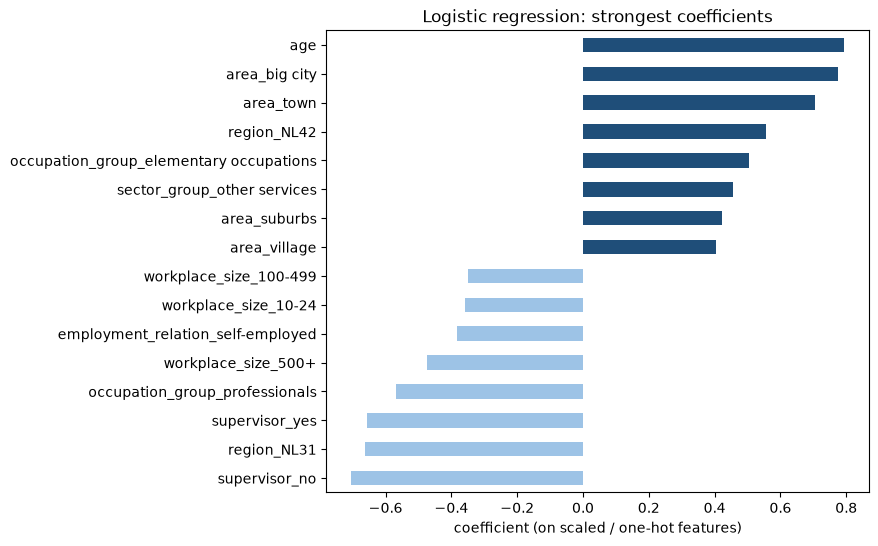

In [25]:
# What does the logistic regression look at? (positive = higher chance of long-term unemployment)
lr_model = searches["Logistic regression"].best_estimator_
names = lr_model.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(lr_model.named_steps["model"].coef_[0], index=names)
# Only show columns that at least 30 people in the training set have: a coefficient for a
# group of a handful of people (e.g. 'area missing' = 1 person) is noise, not an explanation.
Xt = lr_model.named_steps["prep"].transform(X_train)
people = pd.Series(np.asarray((Xt != 0).sum(axis=0)).ravel(), index=names)
coefs = coefs[people >= 30]
coefs.index = coefs.index.str.replace("num__", "").str.replace("cat__", "")
top = pd.concat([coefs.nlargest(8), coefs.nsmallest(8)]).sort_values()
top.plot.barh(figsize=(7, 6), color=np.where(top > 0, "#1f4e79", "#9dc3e6"))
plt.title("Logistic regression: strongest coefficients")
plt.xlabel("coefficient (on scaled / one-hot features)")
plt.show()

**Reading the coefficients.** Dark bars push the predicted risk of long-term unemployment up, light bars push it down. Coefficients of one question must be read *relative to its other answers*:
- **Age** is the strongest single factor: every extra standard deviation of age (about 13 years) clearly raises the risk.
- **Supervisor yes / no** are both negative: compared with the remaining answer – people who *never had a paid job* – anyone who has worked before has a lower risk.
- **Workplace size** and **self-employed** are negative compared with very small workplaces; **professionals** have a lower risk than other occupations, **elementary occupations** a higher one.
- **Area** is positive for every type of place compared with the reference group (farm / countryside), and **region** NL42 (Limburg) is higher, NL31 (Utrecht) lower – regional labour markets differ.

This is what a work coach could explain to a job seeker: *"you are invited early mainly because of your age and because your last job was an elementary job"* – an explanation KNN or a random forest cannot give.

### 9b. Our recommendation to UWV
**We recommend the logistic regression – as support for the work coach, not as a decision-maker.**

**Why this model.**
1. It has the best cross-validation score (0.674) and the smallest spread over the folds (± 0.016), so its performance is the most stable. The random forest (0.672 ± 0.035) is not really worse and KNN (0.643 ± 0.052) only a little: the differences are smaller than the spread, and on the test set all three are within 0.01 of each other. When models perform equally, we choose the one we can explain.
2. It can be explained to the person it is about. Every coefficient shows which characteristic raises or lowers the risk (chart above), so a work coach can tell a job seeker *why* they are invited early. KNN ("you resemble 47 other people") and a forest of 300 trees cannot do that.
3. It beats both alternatives that need no machine learning: inviting everyone (balanced accuracy 0.50) and the age rule (0.59 in cross-validation, 0.56 on the test set). It finds almost twice as many long-term unemployed people as the age rule.

**Which threshold.** At the default threshold of 0.5 the model invites about half of the job seekers early (53% on the test set) and finds 70% of the long-term unemployed. At 0.35 it finds 87%, but invites 73%. Because a missed person is the worse mistake, we advise **0.35 if UWV has the capacity to see about seven in ten people early**, and 0.5 if it does not. That is a capacity decision for UWV; the table in 9a shows exactly what each choice costs.

**Is it good enough? Not to decide on its own.** Roughly one in three predictions is wrong, and the mistakes fall unevenly: the model misses most young long-term unemployed people and about half of the higher-educated ones, and men more often than women. So:
- The model may only **add** people to the early-invitation list. A low score must never mean less help, and a work coach can always invite someone.
- It must never be used for obligations, sanctions or fraud detection. UWV's own research shows the conversation helps; Leiden University (2024) found that imposed obligations backfire.
- Before any real use it must be retrained on recent UWV data of actual WW claimants, and the per-group check in step 8 must be repeated every time.

**Not comparable to UWV's "70% correct".** The Werkverkenner predicts for WW claimants with a questionnaire about attitude and job search, and reports accuracy. We predict for everyone with a recent unemployment spell, from background and previous job only, and report balanced accuracy. Our numbers say nothing about whether the Werkverkenner is better or worse.

## Step 10 – Use it
A new, made-up job seeker at UWV intake. Change the values to try other cases.

In [26]:
new_case = pd.DataFrame([{
    "age": 58,
    "education_level": 3,            # ES-ISCED 3: lower tier upper secondary (about MBO 2-3)
    "father_education": 2,
    "mother_education": 1,
    "household_size": 1,
    "gender": "female",
    "lives_with_partner": "no",
    "children_at_home": "no",
    "area": "village",
    "region": "NL22",                # Gelderland
    "contract": "temporary",
    "employment_relation": "employee",
    "workplace_size": "25-99",
    "supervisor": "no",
    "occupation_group": "clerical support",
    "sector_group": "trade, transport and hospitality",
}])[FEATURES]

probability = best_model.predict_proba(new_case)[0, 1]
print(f"Model: {best_name}, threshold {chosen}")
print(f"Probability of unemployment lasting 12+ months: {probability:.0%}")
print("Advice:", "invite early for a face-to-face conversation" if probability >= chosen
      else "start with online services; regular conversation after 3 months")

Model: Logistic regression, threshold 0.35
Probability of unemployment lasting 12+ months: 80%
Advice: invite early for a face-to-face conversation
